# FFT Harmonics for test bench task:

In [1]:
# automatically reloads imported ```.py```-files once they are changed and saved
%load_ext autoreload
%autoreload 2

In [2]:
# imports required packages
from functools import partial
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
mpl.rcParams.update({'font.size': 20})
import jax
import jax.numpy as jnp

In [3]:
from analytical_harmonics import build_analytical_spectrum, visualize_analytical_spectrum
from helper_functions import triangular_signal, compute_three_phase_signals, three_phase_plot, plot_fft_spectrum, get_fft_spectrum

In [10]:
def compute_three_phase_signals_zsi_minmax(m, u_ref_freq, t, c_t, u_dc):

    omega = u_ref_freq * 2 * jnp.pi
    s_ref_t = jnp.array(
        [
            m * jnp.sin(omega * t),
            m * jnp.sin(omega * t - jnp.pi * 2 / 3),
            m * jnp.sin(omega * t + jnp.pi * 2 / 3),
        ]
    ).T
    
    s_0_t = 0.5 * (jnp.max(s_ref_t, axis=-1) + jnp.min(s_ref_t, axis=-1))
    s_ref_t = s_ref_t - s_0_t[..., None]
    u_ref_t = u_dc / 2  * s_ref_t
    
    s_t = jnp.where(s_ref_t > c_t[..., None], 1, -1)

    return u_ref_t, s_ref_t, s_t, s_0_t


def get_amplitude_at_freq(amps, freqs, target_freq):
    idx = jnp.argmin(jnp.abs(freqs - target_freq))
    return amps[idx]

(20000,)


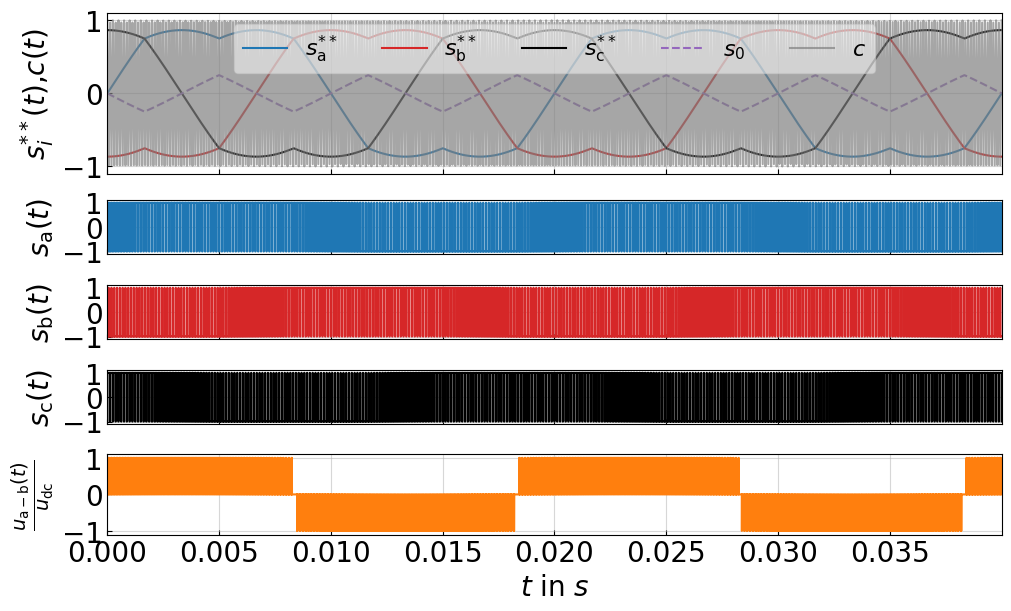

In [11]:
T_full = 0.04 # s
N = 20_000
f_sampling = N / T_full  # 'N' samples per 'T_full' seconds

u_dc = 20  # V
f_fundamental = 50

f_p = 8000  # Hz
T_p = 1 / f_p
t = jnp.linspace(0, T_full, N)
print(t.shape)

c_t = triangular_signal(t, frequency=f_p, amplitude=1.0, phase=0.0)


u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_minmax(
    m=1,
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()

amps, freqs = get_fft_spectrum(s_t[..., 0] - s_t[..., 1], f_sampling, N)

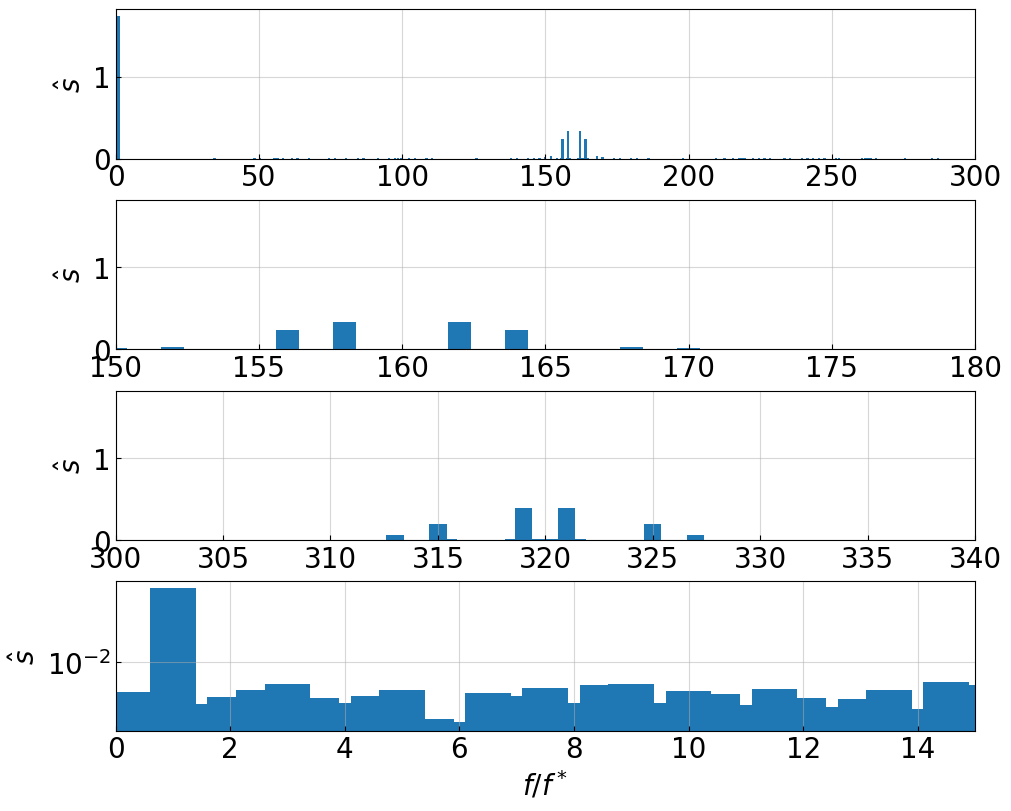

In [12]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8), constrained_layout=True)

for ax in axs:
    ax.set_ylabel("$\\hat{s}$")
    ax.grid(alpha=0.5)
    ax.tick_params(which="major", axis="y", direction="in")
    ax.tick_params(which="both", axis="x", direction="in")

axs[0].bar(freqs[:2500] / f_fundamental, amps[:2500])
axs[0].set_xlim(0, 300)

axs[1].bar(freqs[:2500] / f_fundamental, amps[:2500])
axs[1].set_xlim(150, 180)

axs[2].bar(freqs[:2500] / f_fundamental, amps[:2500])
axs[2].set_xlim(300, 340)

axs[-1].bar(freqs[:100] / f_fundamental, amps[:100])
axs[-1].set_xlim(0, 15)
axs[-1].set_yscale("log")
axs[-1].set_xlabel("$f / f^*$")

plt.show()

In [13]:
print(get_amplitude_at_freq(amps, freqs, target_freq=f_fundamental))

1.7325853


In [14]:
print(get_amplitude_at_freq(amps, freqs, target_freq=f_p))
print(get_amplitude_at_freq(amps, freqs, target_freq=f_p-2*f_fundamental))
print(get_amplitude_at_freq(amps, freqs, target_freq=f_p+2*f_fundamental))

0.0022960615
0.33777115
0.33677825


In [15]:
print(get_amplitude_at_freq(amps, freqs, target_freq=2*f_p))
print(get_amplitude_at_freq(amps, freqs, target_freq=2*f_p-f_fundamental))
print(get_amplitude_at_freq(amps, freqs, target_freq=2*f_p+f_fundamental))

0.012949067
0.3869147
0.39209887
